In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [99]:
df = pd.read_csv("sp_toxigen_v6.csv")
df = df.drop(columns= "Unnamed: 0")

#remove delimiter rows
df = df[df["Episode"] != "Episode"]

# remove blank rows (in v6 rows with only punctuation become blank)
df = df[~df['Line'].isna()]

# assign offensiveness class
df["class"] = np.where(df["prob"] > 90, 1, 0) # 0 is not offensive, 1 is offensive
df['Episode'] = df['Episode'].astype(int)
df['Season'] = df['Season'].astype(int)  # Ensure 'Season' is also an integer
df.head()

# remove lines that are <= 3 words
df['split_line'] = df['Line'].str.split().apply(lambda x: [word for word in x if word.strip() != ""])
df['line_len'] = df['split_line'].apply(len)
df = df[df['line_len'] > 3]

In [32]:
offensive_lines = df[df['class'] == 1]
offensive_lines = offensive_lines.sort_values(by = 'prob')
print(len(offensive_lines))
offensive_lines.to_excel("sp_toxigen_offensive_lines_v6.xlsx")

8795


In [45]:
# group by episode, calculate proportion offensive, plot
episode_means = df.groupby(['Season', 'Episode'])['prob'].mean()
episode_props = df.groupby(['Season', 'Episode'])['class'].mean()

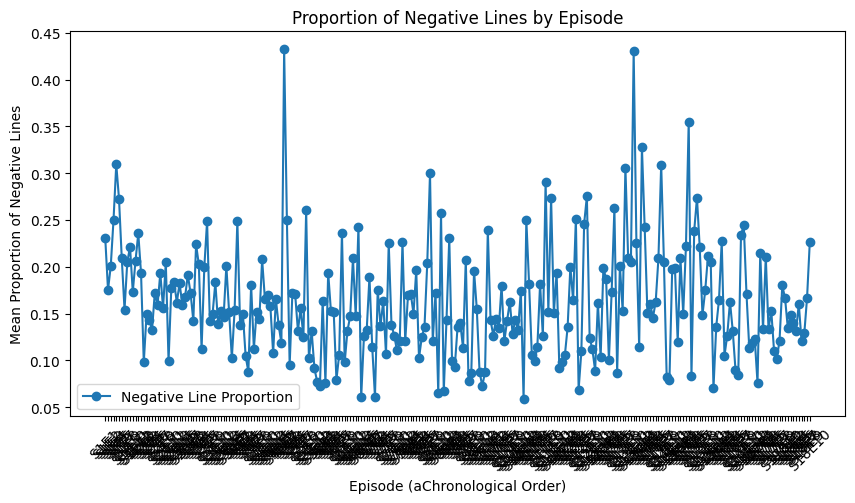

In [46]:
episode_means = df.groupby(['Season', 'Episode'])['class'].mean().reset_index()
episode_means = episode_means.sort_values(by=['Season', 'Episode'])

# Create a continuous x-axis (indexing episodes chronologically)
episode_means['x'] = range(len(episode_means))  # Create a sequential x-axis

# Plot
plt.figure(figsize=(10, 5))
plt.plot(episode_means['x'], episode_means['class'], marker='o', linestyle='-', label="Negative Line Proportion")

# Customize X-axis labels
plt.xticks(episode_means['x'], labels=[f"S{s}E{e}" for s, e in zip(episode_means['Season'], episode_means['Episode'])], rotation=45)

# Labels and Title
plt.xlabel("Episode (aChronological Order)")
plt.ylabel("Mean Proportion of Negative Lines")
plt.title("Proportion of Negative Lines by Episode")
plt.legend()

plt.show()

In [47]:
# look at high outliers

episode_means = episode_means.sort_values(by = 'class', ascending = False)
episode_means.head()
# may want to remove intentionally inflammatory episodes?
# S13, E12 (gay slur), S5 E1 (shit), S15 E4

,Season,Episode,class,x
65,5,1,0.432950,65
192,13,12,0.430303,192
212,15,4,0.355191,212
195,14,1,0.327778,195
4,1,5,0.309524,4


In [48]:
# group by season, calculate proportion offensive, plot
season_means = df.groupby('Season')['prob'].mean()
season_props = df.groupby('Season')['class'].mean()

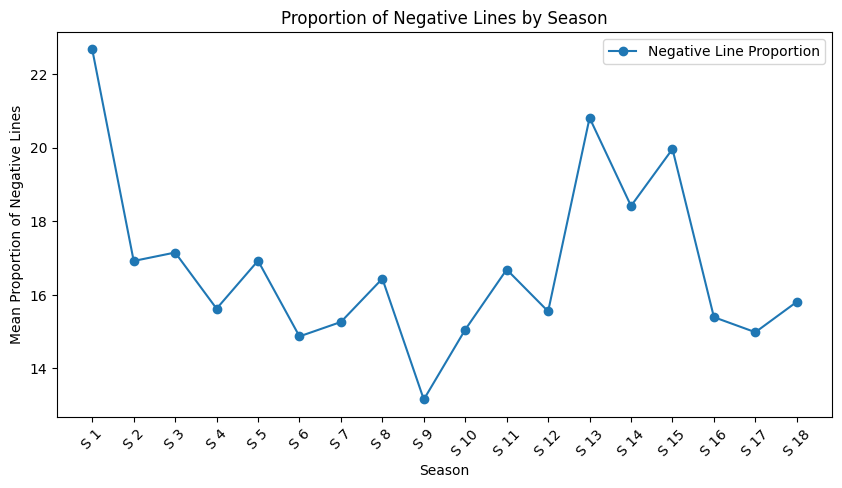

In [49]:
season_means = df.groupby('Season')['prob'].mean().reset_index()
season_means = season_means.sort_values(by=['Season'])

# Create a continuous x-axis (indexing episodes chronologically)
season_means['x'] = range(len(season_means))  # Create a sequential x-axis

# Plot
plt.figure(figsize=(10, 5))
plt.plot(season_means['x'], season_means['prob'], marker='o', linestyle='-', label="Negative Line Proportion")

# Customize X-axis labels
plt.xticks(season_means['x'], labels=[f"S {s}" for s in season_means['Season']], rotation=45)

# Labels and Title
plt.xlabel("Season")
plt.ylabel("Mean Proportion of Negative Lines")
plt.title("Proportion of Negative Lines by Season")
plt.legend()

plt.show()

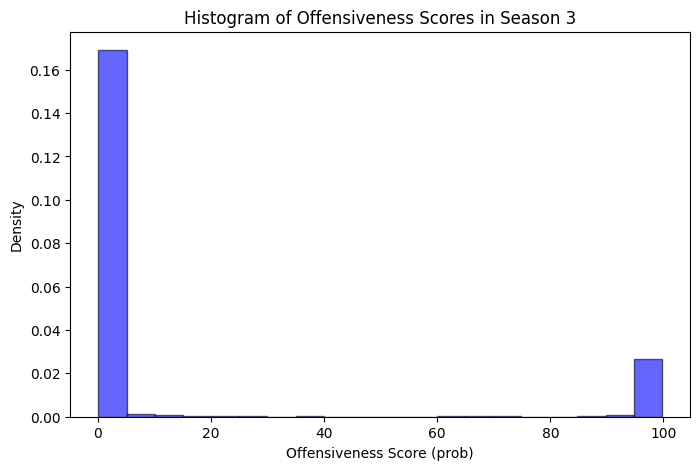

In [54]:
def plot_offensiveness_hist(df, season):
    season_data = df[df['Season'] == season]
    if season_data.empty:
        print(f"No data available for Season {season}.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.hist(season_data['prob'], bins=20, density=True, alpha=0.6, color='blue', edgecolor='black')
    
    plt.xlabel("Offensiveness Score (prob)")
    plt.ylabel("Density")
    plt.title(f"Histogram of Offensiveness Scores in Season {season}")
    
    plt.show()

plot_offensiveness_hist(df, 3)

# none of the distributions are normal
# if restricted to only looking at lines about 80 the distrib is more normal

In [96]:
#ANOVA test - data doesn't meet this assumption
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg

# season needs to be categorical for this
df['Season'] = df['Season'].astype('category')

# check homogeneity of variance
pg.homoscedasticity(data=df, 
                    dv="prob", 
                    group="Season").round(2)
# okay rip not homogenous: use welch's anova

#check normality
model = ols("prob ~ Season", data=df).fit()
res = model.resid
pg.normality(res)

# soooo this is not normal either. can't use anova at all

# run non-parametric Kruskal-Wallis test
pg.kruskal(data=df, 
        dv='prob', 
        between='Season')
# p-val from this is significant


/opt/homebrew/lib/python3.11/site-packages/pingouin/distribution.py:230: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 54293.
  stats = numdata.apply(lambda x: func(x.dropna()), result_type="expand", axis=0).T


,Source,ddof1,H,p-unc
Kruskal,Season,17,196.355764,1.544975e-32


In [100]:
# Fisher tests for class differences btw sequential seasons
from scipy.stats import fisher_exact

def fisher_test(df, season1, season2):
    df['class'] = df['class'].astype(int)
    table = df[df['Season'].isin([season1, season2])].groupby('Season')['class'].value_counts().unstack(fill_value=0)
    oddsratio, p = fisher_exact(table)

    return oddsratio, p, table

pvals = pd.DataFrame({"s1": [], "s2": [], "pval": []})

# get fisher tests for every consecutive season pair
for i in range (1, len(df["Season"].unique())):
    odds_ratio, p_value, table = fisher_test(df, i, i+1)
    pvals.loc[len(pvals)] = [i, i+1, p_value]

# apply holm correction
pvals = pvals.sort_values(by = "pval", ascending = False)
pvals["rank"] = range(1, len(pvals)+1)
pvals["holm_pval"] = pvals["pval"] * pvals["rank"]
pvals["significant"] = pvals["holm_pval"]< 0.05

# significant difference at 0.05: 8&9, 15&16, 12&13, 1&2


In [104]:
# Chi-2 tests for class differences
df['Season'] = df['Season'].astype('category')
df['class'] = df['class'].astype('category')

expected, observed, stats = pg.chi2_independence(df, x='Season', y='class')
print(stats)

                 test    lambda        chi2   dof          pval    cramer  \
0             pearson  1.000000  199.656524  17.0  3.356522e-33  0.060641   
1        cressie-read  0.666667  197.298878  17.0  9.990017e-33  0.060282   
2      log-likelihood  0.000000  193.157217  17.0  6.769601e-32  0.059646   
3       freeman-tukey -0.500000  190.525211  17.0  2.279821e-31  0.059239   
4  mod-log-likelihood -1.000000  188.276853  17.0  6.425278e-31  0.058888   
5              neyman -2.000000  184.864329  17.0  3.090375e-30  0.058352   

   power  
0    1.0  
1    1.0  
2    1.0  
3    1.0  
4    1.0  
5    1.0  
